In [11]:
df = pd.read_csv(r"C:\Users\jhans\OneDrive\ドキュメント\apex\data\raw\archive (3)\WHO COVID-19 cases.csv")

In [13]:
df.head()

,Date_reported,Country_code,Country,Continent,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
0,1/5/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
1,1/12/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
2,1/19/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
3,1/26/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0
4,2/2/2020,AF,Afghanistan,Asia,EMRO,0,0,0,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58560 entries, 0 to 58559
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date_reported      58560 non-null  object
 1   Country_code       58316 non-null  object
 2   Country            58560 non-null  object
 3   Continent          58560 non-null  object
 4   WHO_region         54168 non-null  object
 5   New_cases          58560 non-null  int64 
 6   Cumulative_cases   58560 non-null  int64 
 7   New_deaths         58560 non-null  int64 
 8   Cumulative_deaths  58560 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 4.0+ MB


In [17]:
df.shape

(58560, 9)

In [19]:
df.columns

Index(['Date_reported', 'Country_code', 'Country', 'Continent', 'WHO_region',
       'New_cases', 'Cumulative_cases', 'New_deaths', 'Cumulative_deaths'],
      dtype='object')

In [21]:
df.describe()

,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths
count,5.856000e+04,5.856000e+04,58560.000000,5.856000e+04
mean,1.325372e+04,1.810312e+06,120.582821,2.012550e+04
std,2.212564e+05,7.851277e+06,805.691725,8.220948e+04
min,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,0.000000e+00,4.402750e+03,0.000000,2.900000e+01
50%,4.400000e+01,4.682750e+04,0.000000,5.845000e+02
75%,1.201000e+03,5.351678e+05,12.000000,7.118000e+03
max,4.047548e+07,1.034368e+08,47687.000000,1.197213e+06


In [23]:
df.isnull().sum()

Date_reported           0
Country_code          244
Country                 0
Continent               0
WHO_region           4392
New_cases               0
Cumulative_cases        0
New_deaths              0
Cumulative_deaths       0
dtype: int64

In [25]:
df.drop_duplicates(inplace=True)

In [27]:
df["Date_reported"] = pd.to_datetime(df["Date_reported"])

In [29]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [33]:
df.to_csv(r"C:\Users\jhans\OneDrive\ドキュメント\apex\data\raw\archive (3)\covid_cleaned.csv", index=False)

In [35]:
df["country"].nunique()

240

In [37]:
df["country"].unique()[:10]

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia'], dtype=object)

In [39]:
df["who_region"].value_counts()

who_region
EURO     13420
AFRO     11468
AMRO     11468
WPRO      8296
EMRO      5368
SEARO     2684
OTHER     1464
Name: count, dtype: int64

In [41]:
top_cases = (
    df.groupby("country")["cumulative_cases"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)

print(top_cases)

country
United States of America                                103436829
China                                                    99379039
India                                                    45042802
France                                                   38997490
Germany                                                  38437756
Brazil                                                   37511921
Republic of Korea                                        34571873
Japan                                                    33803572
Italy                                                    26826486
United Kingdom of Great Britain and Northern Ireland     24983630
Name: cumulative_cases, dtype: int64


In [43]:
top_deaths = (
    df.groupby("country")["cumulative_deaths"]
      .max()
      .sort_values(ascending=False)
      .head(10)
)

print(top_deaths)

country
United States of America                                1197213
Brazil                                                   702116
India                                                    533636
Russian Federation                                       403258
Mexico                                                   334673
United Kingdom of Great Britain and Northern Ireland     232112
Peru                                                     220975
Italy                                                    197542
Germany                                                  174979
France                                                   168091
Name: cumulative_deaths, dtype: int64


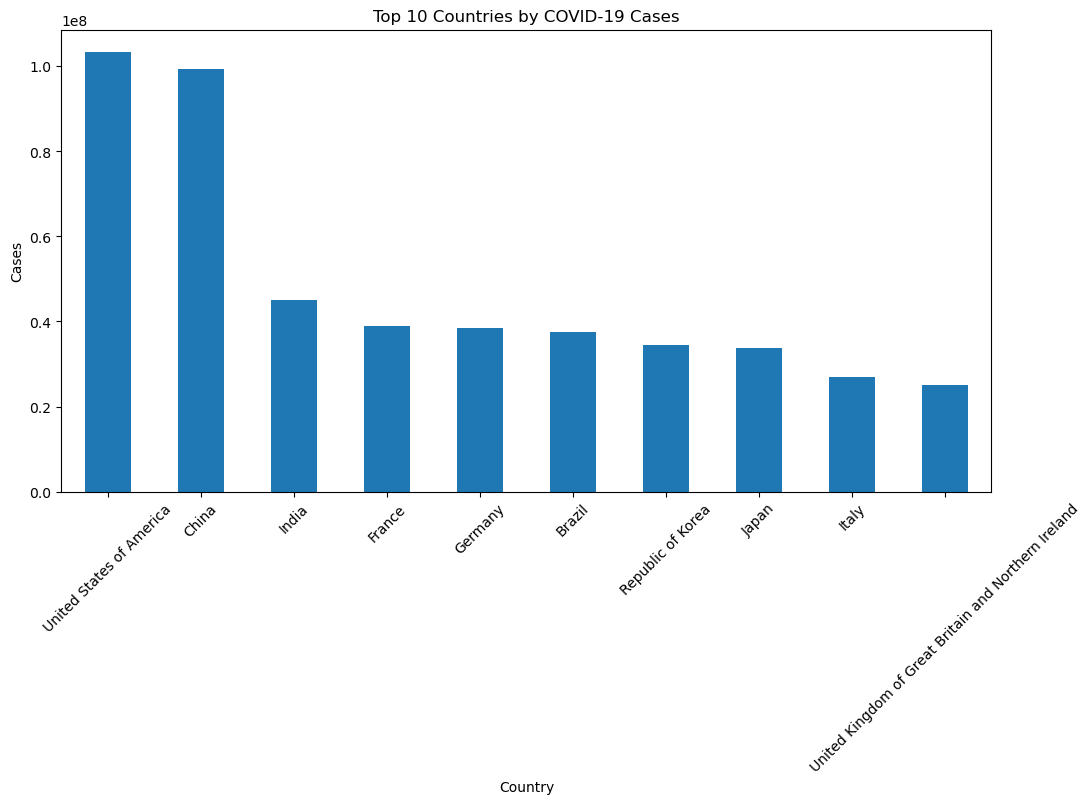

In [45]:
plt.figure(figsize=(12,6))

top_cases.plot(kind="bar")

plt.title("Top 10 Countries by COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Cases")
plt.xticks(rotation=45)

plt.show()

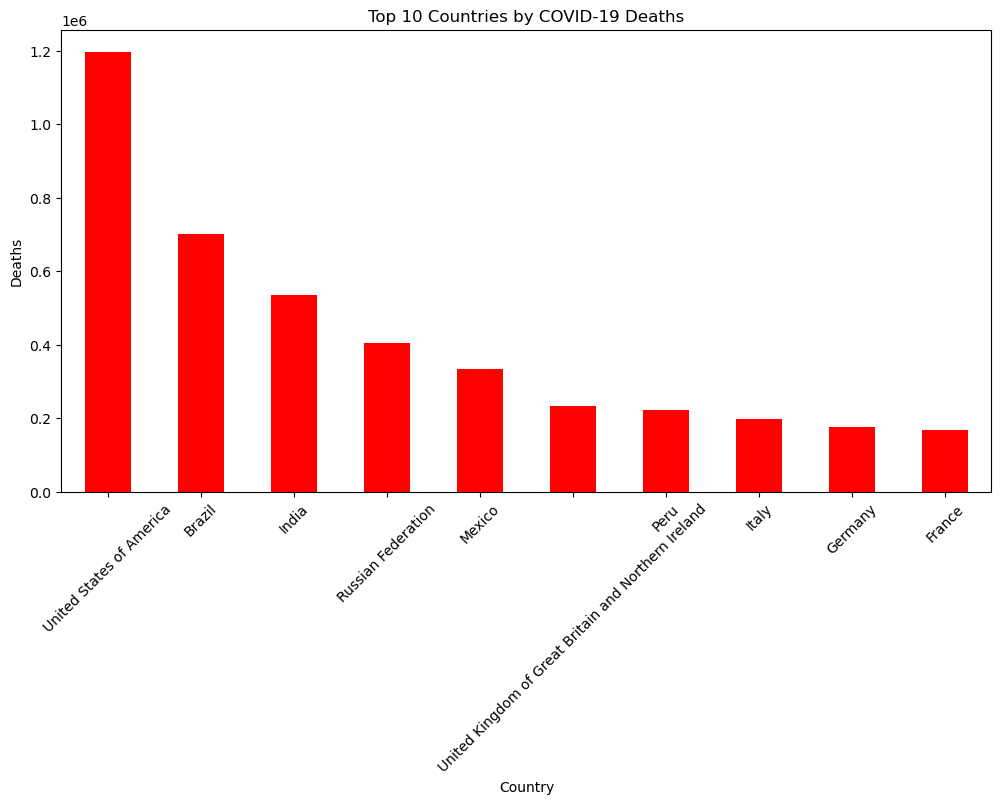

In [47]:
plt.figure(figsize=(12,6))

top_deaths.plot(kind="bar", color="red")

plt.title("Top 10 Countries by COVID-19 Deaths")
plt.xlabel("Country")
plt.ylabel("Deaths")

plt.xticks(rotation=45)

plt.show()

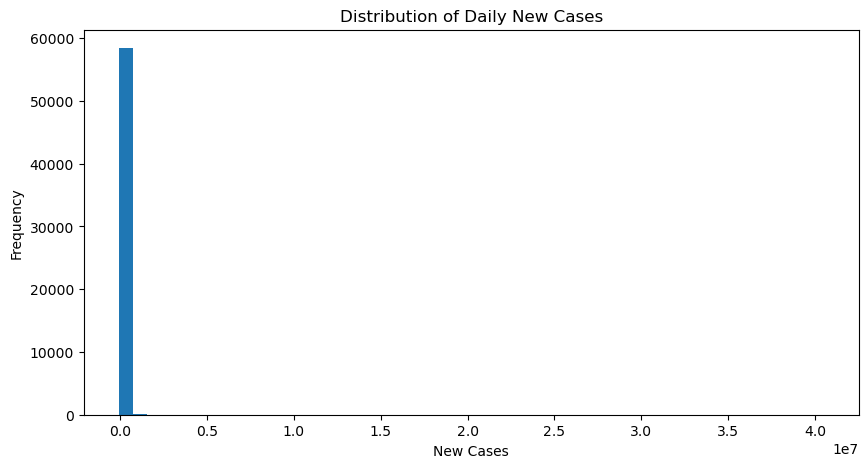

In [49]:
plt.figure(figsize=(10,5))

plt.hist(df["new_cases"], bins=50)

plt.title("Distribution of Daily New Cases")

plt.xlabel("New Cases")

plt.ylabel("Frequency")

plt.show()

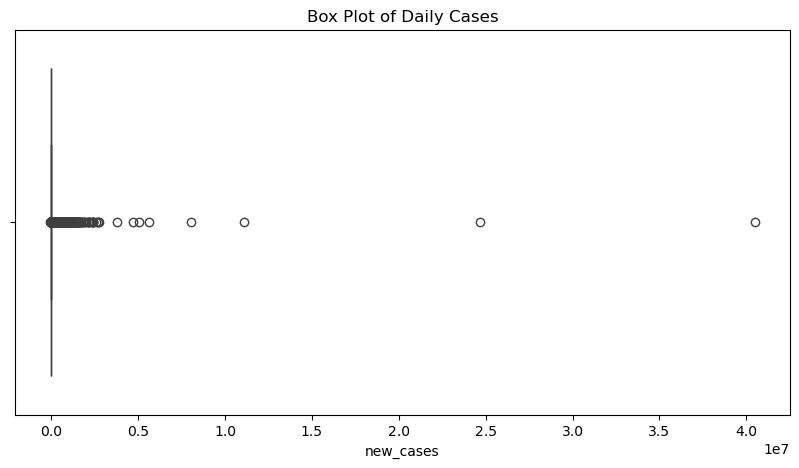

In [51]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["new_cases"])

plt.title("Box Plot of Daily Cases")

plt.show()

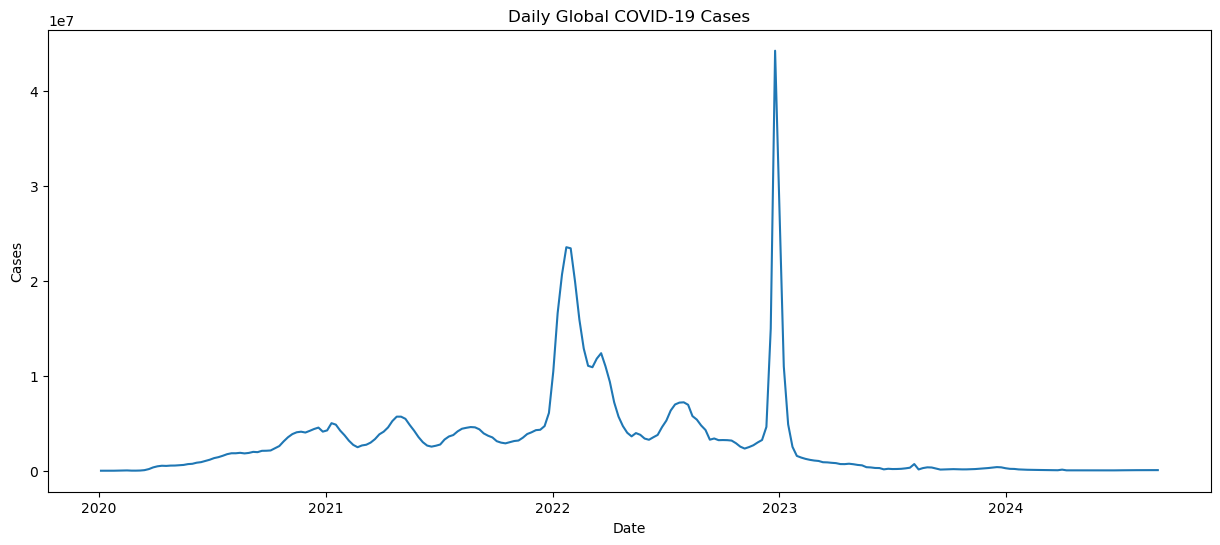

In [53]:
daily_cases = (
    df.groupby("date_reported")["new_cases"]
      .sum()
)

plt.figure(figsize=(15,6))

plt.plot(daily_cases)

plt.title("Daily Global COVID-19 Cases")

plt.xlabel("Date")

plt.ylabel("Cases")

plt.show()

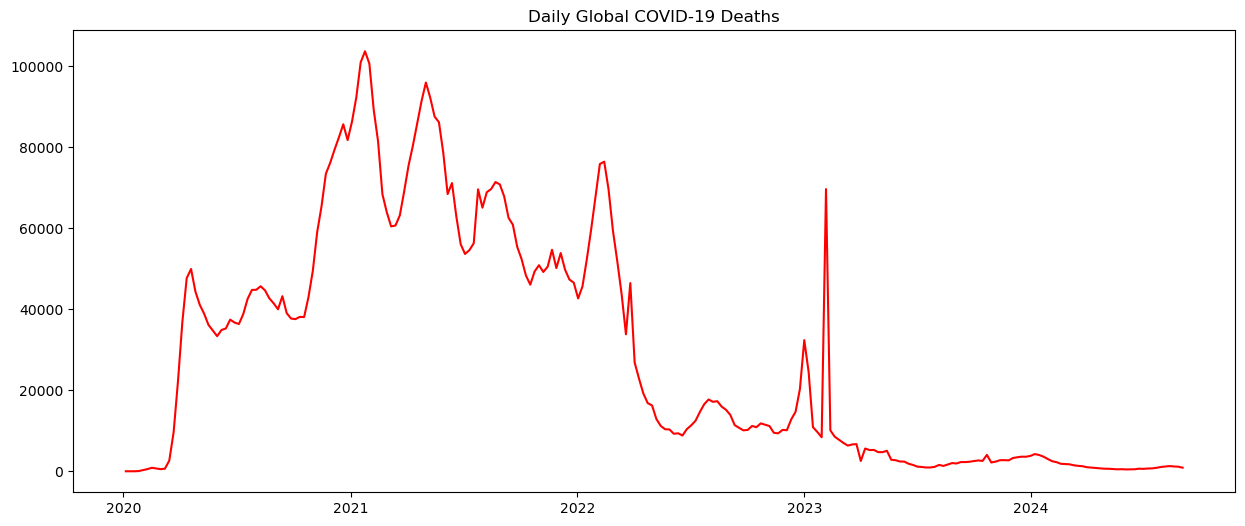

In [55]:
daily_deaths = (
    df.groupby("date_reported")["new_deaths"]
      .sum()
)

plt.figure(figsize=(15,6))

plt.plot(daily_deaths,color="red")

plt.title("Daily Global COVID-19 Deaths")

plt.show()

In [57]:
corr = df[[
    "new_cases",
    "cumulative_cases",
    "new_deaths",
    "cumulative_deaths"
]].corr()

corr

,new_cases,cumulative_cases,new_deaths,cumulative_deaths
new_cases,1.000000,0.162430,0.294423,0.122155
cumulative_cases,0.162430,1.000000,0.234503,0.792750
new_deaths,0.294423,0.234503,1.000000,0.342313
cumulative_deaths,0.122155,0.792750,0.342313,1.000000


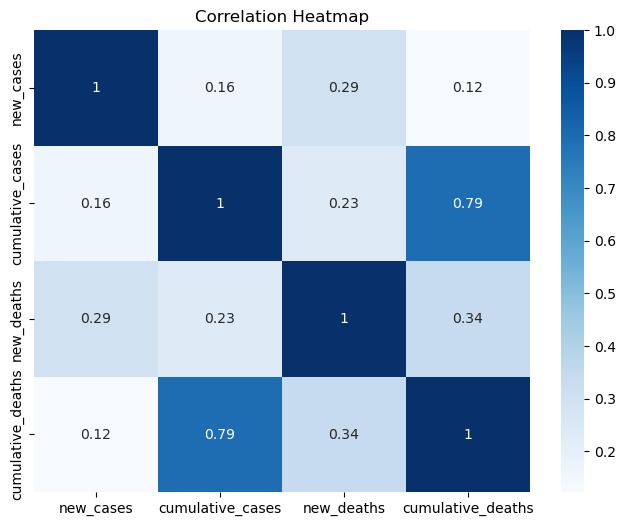

In [59]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()